# Day 10：收官之战 —— 从零搭建完整 LSTM 应用> ⏳ 第十周 · 记忆的诞生 · 第 10 天这是阶段五的收官之日。过去九天，我们从"金鱼记忆"出发，认识了 RNN、发现了梯度消失、学习了 LSTM 的门控机制、了解了 GRU 的精简设计、实现了文本生成和 Seq2Seq 翻译。今天，我们要把所有知识融会贯通，从零搭建一个完整的 LSTM 应用：**姓名国籍分类器**。**今天的任务**：1. 从零搭建完整的字符级 LSTM 分类器2. 在真实数据上训练并评估3. 全面回顾这两周学到的核心知识---

## 1. 历史剧场：RNN/LSTM 的遗产从 1997 年 LSTM 诞生到 2017 年 Transformer 出现，LSTM 统治了序列建模整整 20 年。**LSTM 的思想遗产**：- **门控机制**：选择性记忆和遗忘——这个思想影响了后来的 GAN、Transformer- **加法更新**：类似 ResNet 的跳跃连接，让梯度保底- **序列建模范式**：逐个处理输入，维护内部状态——这是所有序列模型的基石即使 Transformer 已经成为主流，LSTM 仍然在以下场景中活跃：- **小数据集**：LSTM 参数少，不容易过拟合- **实时流数据**：LSTM 可以逐个处理，不需要等全部输入- **边缘设备**：LSTM 计算量小，适合手机和嵌入式设备---

## 2. 生活隐喻：从零训练一个"语言侦探"今天我们要做的，就像训练一个"语言侦探"：给他一个名字，他能根据名字的拼写模式，判断这个人来自哪个国家：- "Zhang" → 中文- "Smith" → 英文- "Müller" → 德文- "Tanaka" → 日文LSTM 逐字符读取名字，通过拼写模式（如"zh"、"ll"、"aka"）判断国籍。---

## 3. 代码实验室：姓名国籍分类器

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.1 构建数据集

In [ ]:
names_data = {    '中文': ['Wang', 'Li', 'Zhang', 'Liu', 'Chen', 'Yang', 'Huang', 'Zhao',             'Zhou', 'Wu', 'Xu', 'Sun', 'Ma', 'Zhu', 'Hu', 'Lin', 'Guo',             'He', 'Luo', 'Zheng'],    '英文': ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Miller',             'Davis', 'Garcia', 'Rodriguez', 'Wilson', 'Taylor', 'Thomas',             'Moore', 'Jackson', 'Martin', 'Lee', 'Clark', 'Walker',             'Hall', 'Allen'],    '日文': ['Tanaka', 'Suzuki', 'Takahashi', 'Watanabe', 'Ito', 'Yamamoto',             'Nakamura', 'Kobayashi', 'Saito', 'Kato', 'Yoshida', 'Yamada',             'Sasaki', 'Yamashita', 'Ishida', 'Ogawa', 'Matsumoto',             'Inoue', 'Kimura', 'Hayashi'],    '韩文': ['Kim', 'Lee', 'Park', 'Choi', 'Jung', 'Kang', 'Cho', 'Yoon',             'Jang', 'Lim', 'Han', 'Oh', 'Shin', 'Seo', 'Ryu', 'Park',             'Baek', 'Hwang', 'Yoo', 'Song']}all_letters = set()for names in names_data.values():    for name in names:        all_letters.update(name.lower())all_letters = sorted(all_letters)letter_to_idx = {c: i+1 for i, c in enumerate(all_letters)}n_letters = len(all_letters) + 1categories = list(names_data.keys())cat_to_idx = {c: i for i, c in enumerate(categories)}n_categories = len(categories)print(f"字符数: {n_letters}")print(f"类别数: {n_categories}")print(f"总样本数: {sum(len(v) for v in names_data.values())}")

### 3.2 数据准备

In [ ]:
def name_to_tensor(name):    indices = [letter_to_idx.get(c.lower(), 0) for c in name]    return torch.tensor(indices, dtype=torch.long)X_list, y_list = [], []for cat, names in names_data.items():    for name in names:        X_list.append(name_to_tensor(name))        y_list.append(cat_to_idx[cat])print(f"示例: '{names_data['中文'][0]}' → {name_to_tensor(names_data['中文'][0])}")print(f"标签: 中文=0, 英文=1, 日文=2, 韩文=3")

### 3.3 定义 LSTM 分类器

In [ ]:
class NameClassifier(nn.Module):    def __init__(self, n_letters, embed_dim, hidden_dim, n_categories, n_layers=2):        super().__init__()        self.hidden_dim = hidden_dim        self.n_layers = n_layers        self.embedding = nn.Embedding(n_letters, embed_dim, padding_idx=0)        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers,                           batch_first=True, dropout=0.1)        self.fc = nn.Linear(hidden_dim, n_categories)    def forward(self, x):        emb = self.embedding(x)        _, (h_n, _) = self.lstm(emb)        out = self.fc(h_n[-1])        return outmodel = NameClassifier(n_letters, embed_dim=16, hidden_dim=64,                       n_categories=n_categories, n_layers=2)total_params = sum(p.numel() for p in model.parameters())print(f"模型参数量: {total_params:,}")

### 3.4 训练

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)loss_fn = nn.CrossEntropyLoss()losses = []accuracies = []for epoch in range(300):    total_loss = 0    correct = 0    total = 0    indices = torch.randperm(len(X_list))    for idx in indices:        x = X_list[idx].unsqueeze(0)        y = torch.tensor([y_list[idx]])        out = model(x)        loss = loss_fn(out, y)        optimizer.zero_grad()        loss.backward()        nn.utils.clip_grad_norm_(model.parameters(), 1.0)        optimizer.step()        total_loss += loss.item()        pred = out.argmax(dim=1)        correct += (pred == y).sum().item()        total += 1    losses.append(total_loss / total)    accuracies.append(correct / total)    if (epoch + 1) % 50 == 0:        print(f"Epoch {epoch+1:3d} | Loss: {losses[-1]:.4f} | Acc: {accuracies[-1]:.2%}")

### 3.5 测试与可视化

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))axes[0].plot(losses, color='#3498db', alpha=0.8)axes[0].set_xlabel('Epoch', fontsize=12)axes[0].set_ylabel('Loss', fontsize=12)axes[0].set_title('训练损失', fontsize=14)axes[0].grid(True, alpha=0.3)axes[1].plot(accuracies, color='#27ae60', alpha=0.8)axes[1].set_xlabel('Epoch', fontsize=12)axes[1].set_ylabel('准确率', fontsize=12)axes[1].set_title('训练准确率', fontsize=14)axes[1].grid(True, alpha=0.3)plt.tight_layout()plt.show()

### 3.6 交互测试

In [ ]:
def predict_nationality(name):    x = name_to_tensor(name).unsqueeze(0)    with torch.no_grad():        out = model(x)        probs = torch.softmax(out, dim=1)        confidence, pred = probs.max(dim=1)    return categories[pred.item()], confidence.item()test_names = ['Chen', 'Johnson', 'Sato', 'Park', 'Wang', 'Miller',              'Nakamura', 'Jung', 'Liu', 'Williams']print("姓名国籍预测：")print("-" * 40)for name in test_names:    nat, conf = predict_nationality(name)    print(f"  {name:12s} → {nat} (置信度: {conf:.2%})")

---

## 4. 阶段五总结：记忆的诞生这两周我们学到了什么？| 天数 | 主题 | 核心概念 ||---|---|---|| Day 01 | 金鱼记忆 | 前馈网络没有记忆，无法处理序列 || Day 02 | RNN 的隐藏状态 | $h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b)$ || Day 03 | 梯度消失 | RNN 只能记住最近几步 || Day 04 | LSTM 的三个门 | 遗忘门、输入门、输出门 + 细胞状态 || Day 05 | LSTM vs RNN | LSTM 碾压 RNN，加法更新是关键 || Day 06 | 词嵌入 | 把文字变成有意义的向量 || Day 07 | GRU | LSTM 的精简版，两个门就够了 || Day 08 | 文本生成 | 逐字预测 + 温度控制 || Day 09 | Seq2Seq | Encoder-Decoder + 信息瓶颈 || Day 10 | 收官实战 | 姓名国籍分类器 |**核心洞察**：1. **记忆的本质**：维护一个随时间更新的内部状态2. **LSTM 的关键**：加法更新（类似 ResNet）让梯度保底3. **门控的智慧**：选择性记忆和遗忘4. **Seq2Seq 的瓶颈**：固定向量无法表示长序列> 这个瓶颈，将在下一阶段被**注意力机制**彻底解决。---

<p align="center">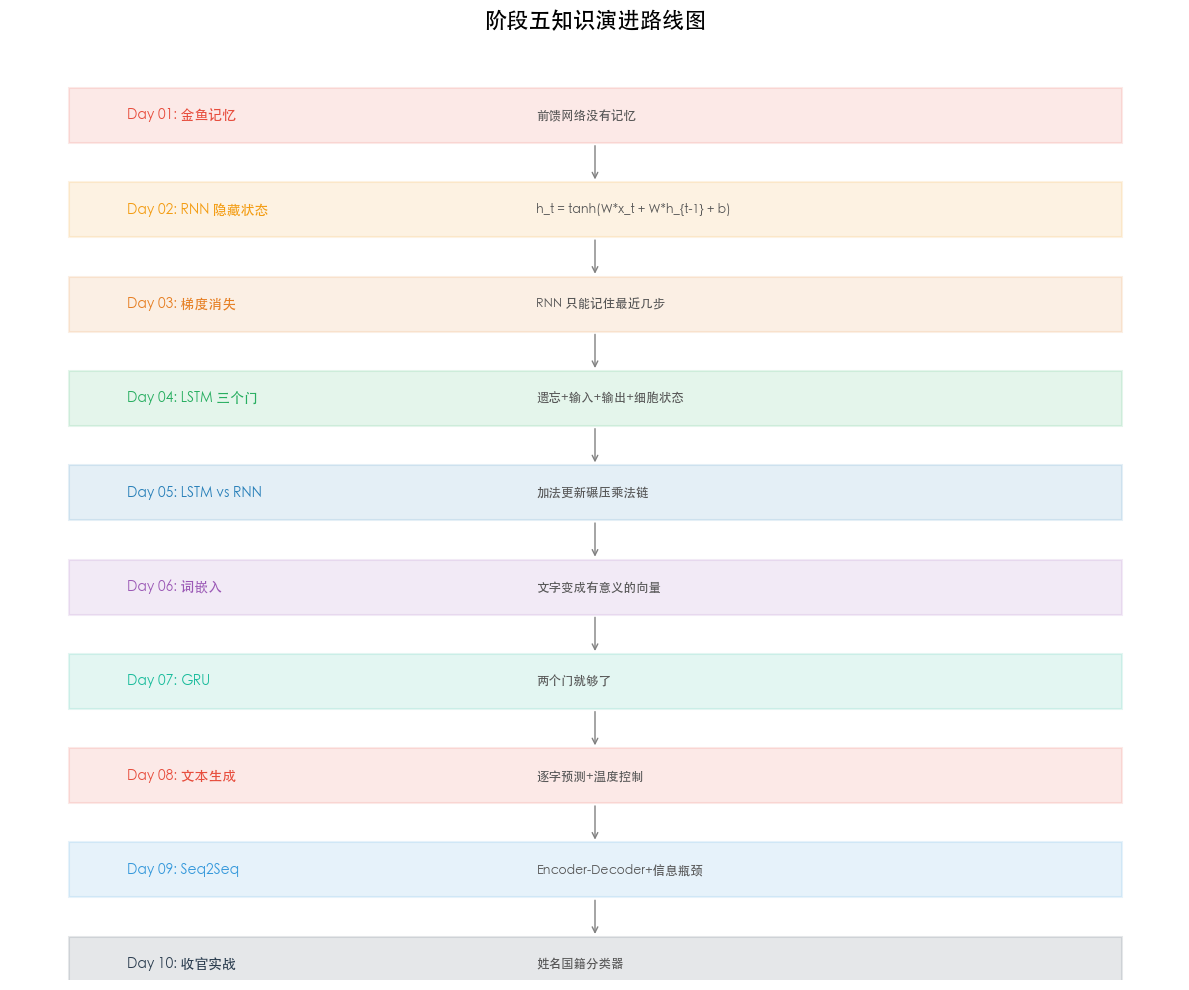</p>*阶段五知识路线图*

## 今日结语今天我们从零搭建了一个完整的 LSTM 应用。回顾这两周：我们见证了神经网络从"金鱼"进化到"大象"——RNN 有了记忆，LSTM 有了长记忆。但 LSTM 仍然有一个根本限制：它必须**按顺序**处理输入，一个字一个字地看。如果有一种方法，能让模型**一次性看到所有信息**，并且**自动关注最重要的部分**呢？> 这就是下一阶段的主角——**注意力机制**。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 语言侦探——根据拼写判断国籍 | 字符级分类——LSTM 逐字符读取并分类 || 从金鱼到大象 | 从 RNN 到 LSTM——短记忆到长记忆 || 选择性记忆 | 门控机制——遗忘/输入/输出 || 加法 = 保底 | 加法更新——梯度无损传递 || 逐字看，一个不落 | 序列处理——RNN/LSTM 的方式 || 一次性看全部并聚焦重点 | 注意力机制（预告！） |